<a href="https://colab.research.google.com/github/gekkota2356/Analisis_Exploratorio_Pozos/blob/main/Analisis_bivariado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from google.colab import files

In [ ]:
uploaded = files.upload()

Saving Pozo-1_reg.csv to Pozo-1_reg.csv


In [ ]:
logs = pd.read_csv('Pozo-1_reg.csv', sep=',',header=[0,1])
logs = logs.replace(-999.25,np.nan)
print(logs.head(5))

         DEPTH          GR         RT      NPHI      RHOB         DT
             m         API      ohm.m       v/v      g/cc      us/ft
0  1000.000000   87.450712  11.741021  0.319968  2.427836  83.248217
1  1004.008016   77.926035  19.196123  0.296232  2.294881  88.554813
2  1008.016032   89.715328   3.671926  0.252982  2.268180  82.075801
3  1012.024048  102.845448   9.791206  0.217653  2.349663  86.920385
4  1016.032064   76.487699   5.337080  0.284911  2.332982        NaN


In [ ]:
def estadistica_descriptiva(df):
   #Filtrar solo considerar valorese numericos
  df_numerico = df.select_dtypes(include=['number'])

  if df_numerico.empty:
    return "no hay columnas numericas en el DataFrame."

  # calcular la estadisitca descriptiva
  stats= df_numerico.describe().T

  #Agragar estadistica adicional
  stats['simetria'] = df_numerico.skew()
  stats['curtosis'] = df_numerico.kurtosis()
  stats['Rango'] = stats['max']-stats['min']
  stats['Rango intercuartil'] = stats['75%']-stats['25%']
  stats['varianza'] = df_numerico.var()

  stats= stats.round(2)

  return stats.T

In [ ]:
estadistica_descriptiva(logs)

,DEPTH,GR,RT,NPHI,RHOB,DT
,m,API,ohm.m,v/v,g/cc,us/ft
count,500.00,485.00,485.00,485.00,485.00,485.00
mean,2000.00,80.11,8.41,0.26,2.35,89.84
std,579.09,14.51,4.38,0.05,0.10,9.58
min,1000.00,31.38,1.92,0.11,2.06,59.80
25%,1500.00,69.50,5.44,0.22,2.29,83.42
50%,2000.00,80.20,7.49,0.26,2.35,89.91
75%,2500.00,89.68,10.22,0.29,2.42,96.66
max,3000.00,126.18,27.56,0.38,2.67,121.10
simetria,0.00,0.10,1.50,-0.05,-0.08,0.01


In [ ]:
def Histograma_Boxplot(df, bins="sturges", stat="percent", color="lightblue", lan="esp", cum=False, kde=False):
    #Filtrar solo considerar valorese numericos y excluir la profundidad
    df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')

    if df_numerico.empty:
        return "no hay columnas numericas en el DataFrame."

    # iterar para generar graficos para cada variable
    for column in df_numerico.columns:
      datos = df_numerico[column].dropna()

      #calcular estdistica basica
      media = datos.mean()
      mediana = datos.median()

      # crear los graficos(boxplot, luego el hsitograma)
      f, (ax_box,ax_his) = plt.subplots(2, sharex = True, gridspec_kw={"height_ratios":(0.15,0.85)})

      #Crear el boxplot
      sns.boxplot(x = datos, orient = "h",color = color, notch = True, ax = ax_box)
      ax_box.axvline(media, color = "red", linestyle = "dashed", label = "Media")
      ax_box.axvline(mediana, color ="blue", linestyle = "dashed", label = "Mediana")

      #Crear el histograma
      sns.histplot(datos, bins = bins, stat = stat, color = color,ax = ax_his,cumulative = cum,kde = kde)
      ax_his.axvline(media, color="red", linestyle = "dashed", label = "Media")
      ax_his.axvline(mediana, color = "blue", linestyle = "dashed", label = "Mediana")

      #Congfigurar la leyenda y ejes
      if lan == "esp":
          ax_his.legend(labels = ["Media", "Mediana"])
          ax_his.set_xlabel("Valores: ")
      elif lan == "eng":
          ax_his.legend(labels = ["Mean", "Median"])
          ax_his.set_xlabel("Vaules: ")

      # configurar la cuadricula en ambos graficos
      ax_box.grid(True,axis = "both", linestyle='--',alpha = 0.7)
      ax_his.grid(True,axis = "both", linestyle='--',alpha = 0.7)

      # Personalizar bordes y eleminar escalas de boxplot
      for ax in [ax_box, ax_his]:
        for spine in ax.spines.values():
          spine.set_edgecolor('black')

      ax_box.set(yticks=[])

      # Mostrar graficos
      plt.tight_layout()
      plt.show()

/tmp/ipython-input-45842210.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')


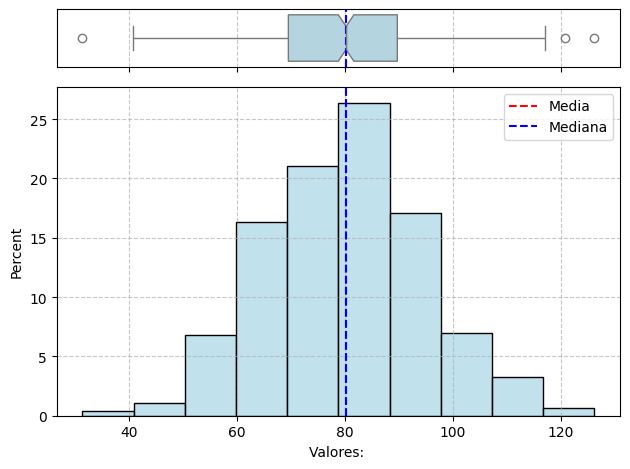

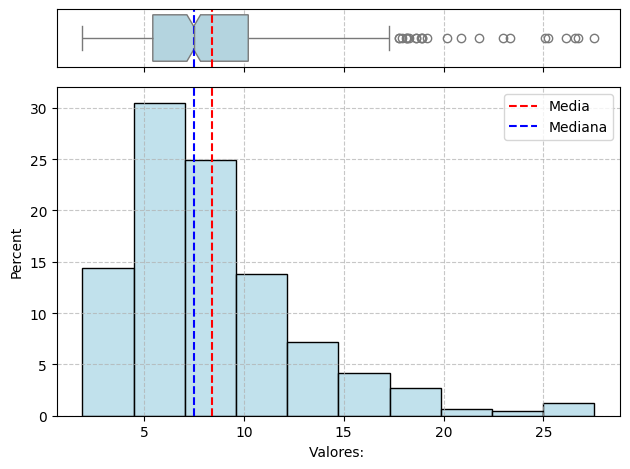

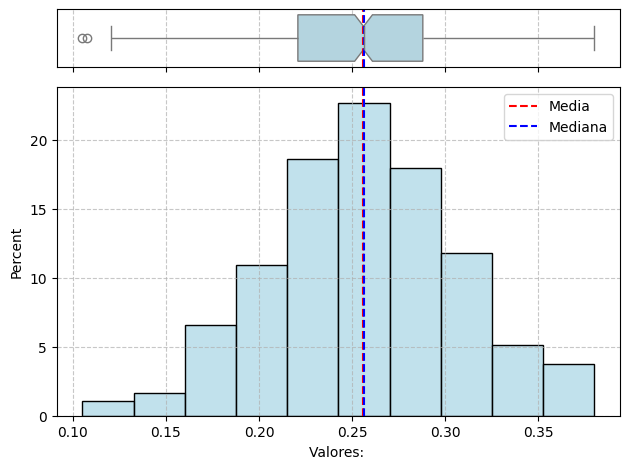

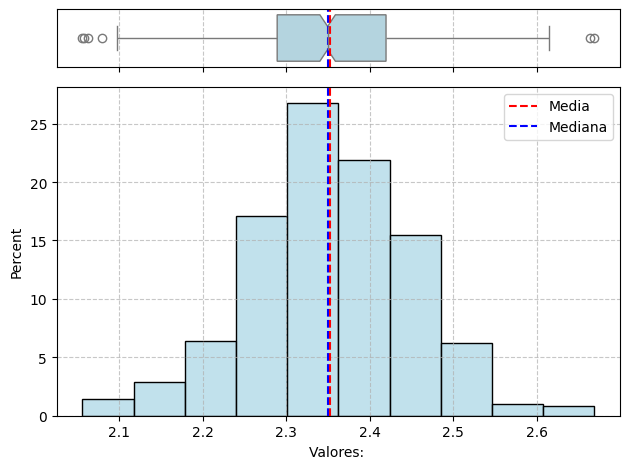

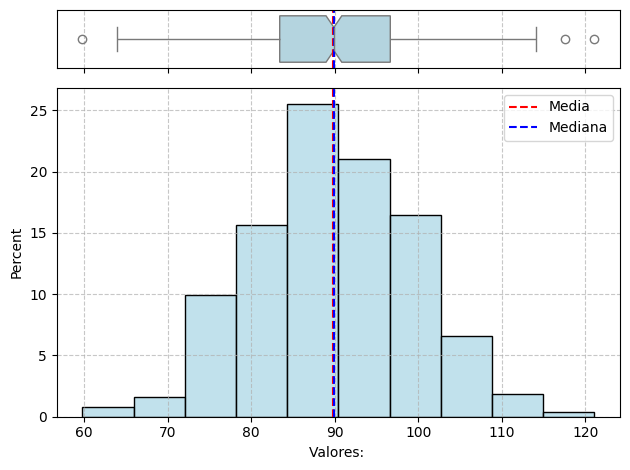

In [ ]:
Histograma_Boxplot(logs)

In [ ]:
def graficoQQ(df,dist='norm',color="blue"):
  #Filtrar solo considerar valorese numericos y excluir la profundidad
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')

  if df_numerico.empty:
      return "no hay columnas numericas en el DataFrame."

  # iterar para generar graficos para cada variable
  for column in df_numerico.columns:
    datos=df_numerico[column].dropna()

    #Crear el grafico
    plt.figure(figsize=(6,6))
    stats.probplot(datos,dist=dist,plot=plt)

    #Pesonalizar el grafico
    plt.title(f'QQ plot de {column}')
    plt.grid(True)
    plt.gca().get_lines()[0].set_color(color)
    plt.show()

/tmp/ipython-input-3663055074.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')


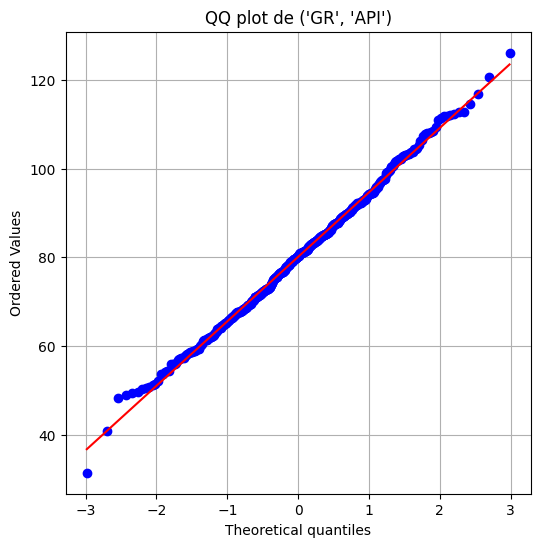

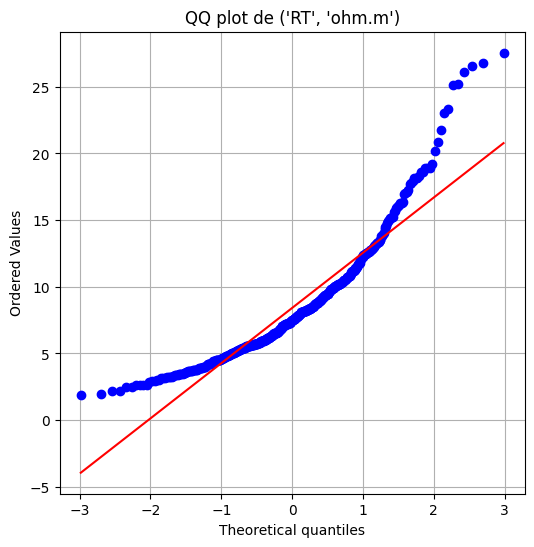

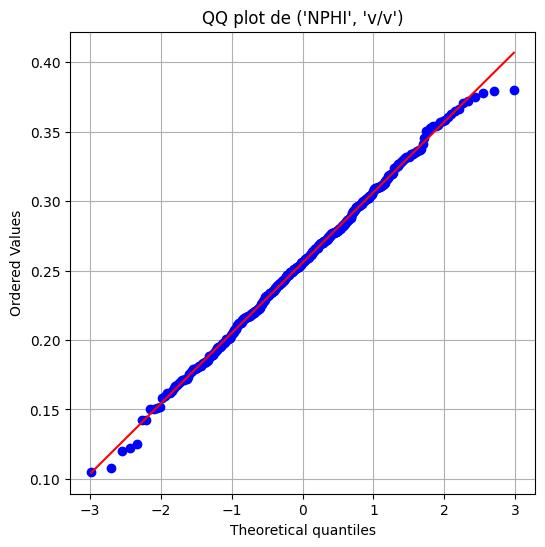

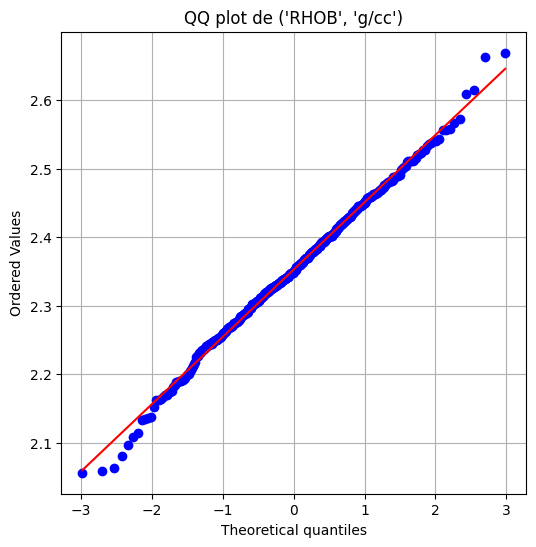

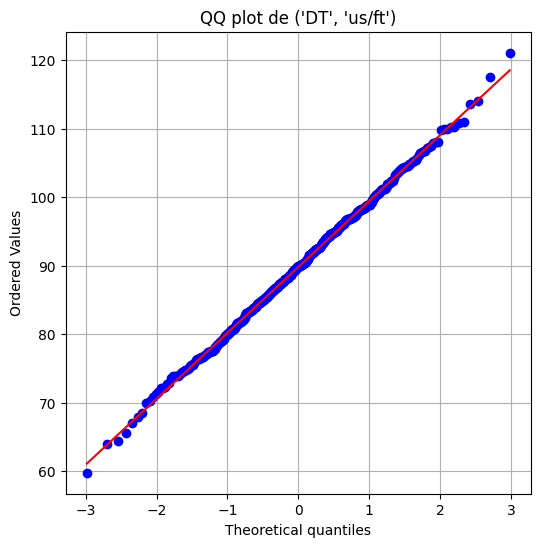

In [ ]:
graficoQQ(logs)

In [ ]:
def identificar_outlier(df):
   #Filtrar solo considerar valorese numericos y excluir la profundidad
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')

  if df_numerico.empty:
        return "no hay columnas numericas en el DataFrame."

  outliers_dict={}


    # iterar para generar graficos para cada variable
  for column in df_numerico.columns:
    datos=df_numerico[column].dropna()

        # calcular los cuartiles y el rango intercuartil
    Q1= np.percentile(datos, 25)
    Q3= np.percentile(datos, 75)
    IQR= Q3-Q1

      # Definir los limites superior e inferior del bloxplot
    limite_superior = Q3 + 1.5 * IQR
    limite_inferior = Q1 - 1.5 * IQR


    outliers= datos[(datos< limite_inferior) | (datos > limite_superior)]
    indices = outliers.index.tolist()

    if not outliers.empty:
        outliers_dict[column] = {
            "ouitliers": outliers.tolist(),
            "indices":indices,
            "num outliers": len(outliers)
        }

  return outliers_dict

In [ ]:
outliears_info = identificar_outlier(logs)
for column, info in outliears_info.items():
  print(f"\n Columna: {column}")
  print(f"Numero de valores atipicos: {info['num outliers']}\n")


 Columna: ('GR', 'API')
Numero de valores atipicos: 3


 Columna: ('RT', 'ohm.m')
Numero de valores atipicos: 24


 Columna: ('NPHI', 'v/v')
Numero de valores atipicos: 2


 Columna: ('RHOB', 'g/cc')
Numero de valores atipicos: 6


 Columna: ('DT', 'us/ft')
Numero de valores atipicos: 3



/tmp/ipython-input-1900925449.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')


In [ ]:
def eliminar_outlier(df):
#Filtrar solo considerar valorese numericos y excluir la profundidad
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')

  if df_numerico.empty:
          return "no hay columnas numericas en el DataFrame."

  df_outliers_nan= df.copy()


      # iterar para generar graficos para cada variable
  for column in df_numerico.columns:
    datos=df_numerico[column].dropna()
    # calcular los cuartiles y el rango intercuartil
    Q1= np.percentile(df, 25)
    Q3= np.percentile(df, 75)
    IQR= Q3-Q1

    # Definir los limites superior e inferior del bloxplot
    limite_superior = Q3 + 1.5 * IQR
    limite_inferior = Q1 - 1.5 * IQR

    # eliminar los outliers
    df_outliers_nan.loc[(df_outliers_nan[column] < limite_inferior) |
                            (df_outliers_nan[column] > limite_superior),column ]= np.nan

  return df_outliers_nan

In [ ]:
logs_sin_outliers = eliminar_outlier(logs)

print(f"Tamaño original: {logs.shape}")
print(f"Tamaño despues de eleminar outliers: {logs_sin_outliers.shape}")

print(logs_sin_outliers.isna().sum())

Tamaño original: (500, 6)
Tamaño despues de eleminar outliers: (500, 6)
DEPTH  m         0
GR     API      15
RT     ohm.m    15
NPHI   v/v      15
RHOB   g/cc     15
DT     us/ft    15
dtype: int64


/tmp/ipython-input-1325846970.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')


/tmp/ipython-input-45842210.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')


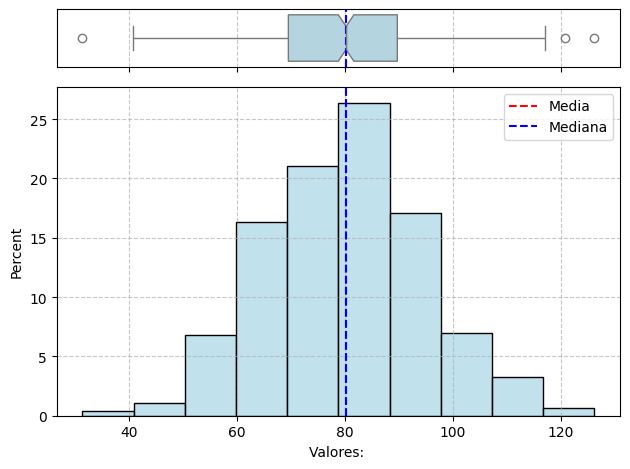

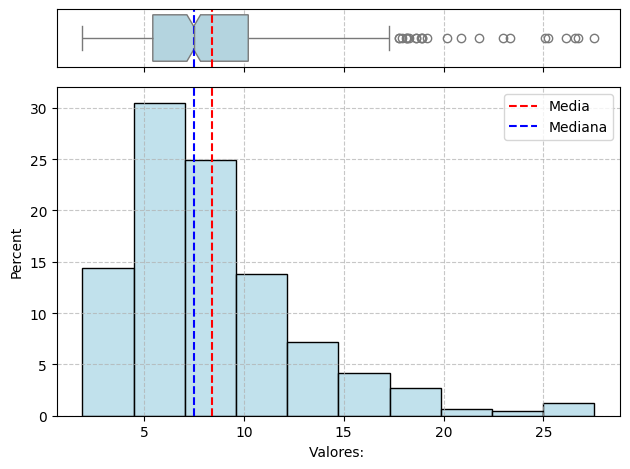

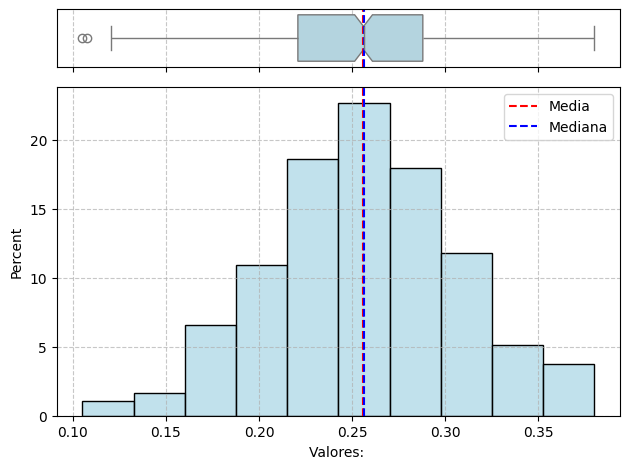

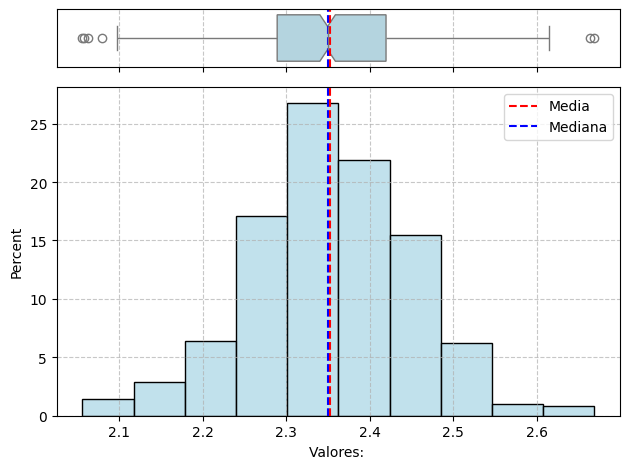

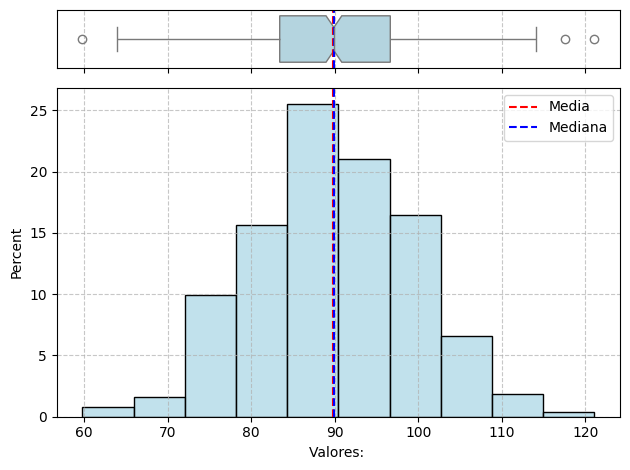

In [ ]:
Histograma_Boxplot(logs_sin_outliers)

In [ ]:
def mapa_calor_dependencia(df,metodo='pearson',cmap='seismic',annot=True):
  #Filtrar solo considerar valorese numericos y excluir la profundidad
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')

  if df_numerico.empty:
    return "no hay columnas numericas en el DataFrame."

    #calcular la matriz de dependencia
  matriz =df_numerico.corr(method=metodo)

    #crear el mapa de calor
  plt.figure(figsize=(8,6))
  sns.heatmap(matriz,vmin=-1,annot=annot, fmt="0.2f", cmap=cmap, linewidths=0.5, square=True)

    #configuracione
  plt.title(f"Matriz de dependencia {metodo.capitalize()}", fontsize=14)
  plt.show()

/tmp/ipython-input-3246213062.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')


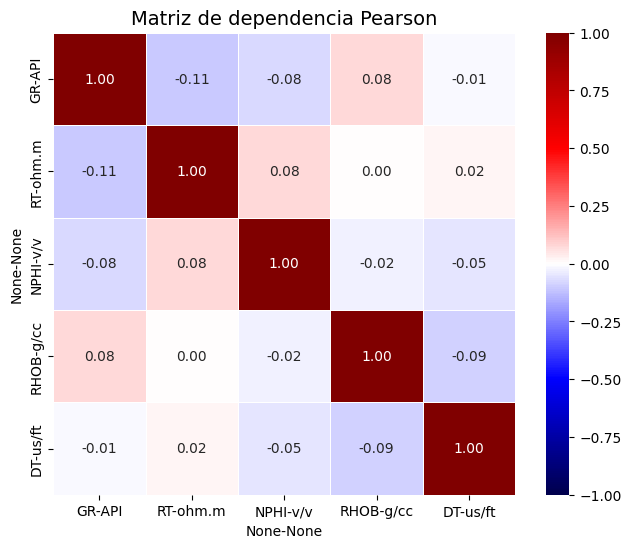

/tmp/ipython-input-3246213062.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')


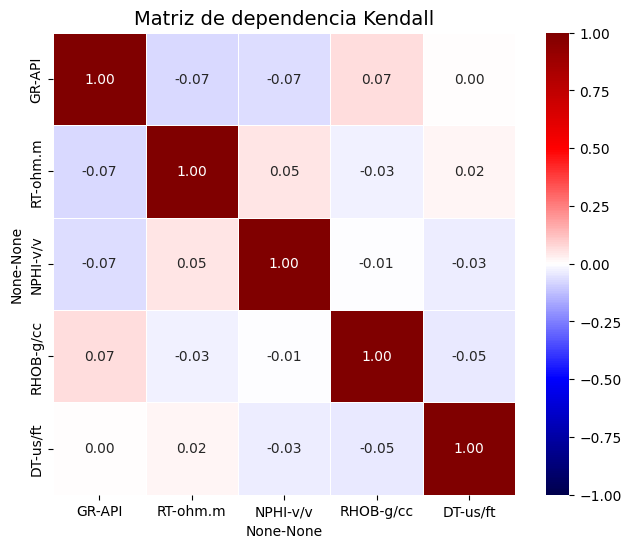

/tmp/ipython-input-3246213062.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_numerico = df.select_dtypes(include=['number']).drop(columns=['DEPTH'],errors='ignore')


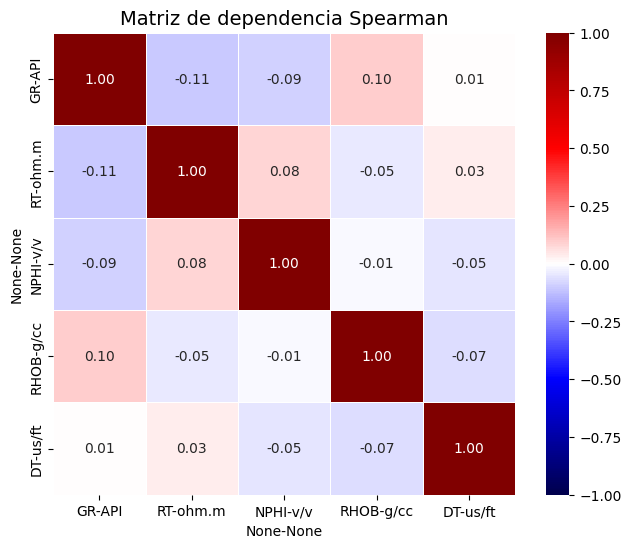

In [ ]:
mapa_calor_dependencia(logs,metodo='pearson')
mapa_calor_dependencia(logs,metodo='kendall')
mapa_calor_dependencia(logs,metodo='spearman')

In [ ]:
# @title
